# Sales Prediction using Python
Sales prediction involves forecasting the amount of a product that
customers will purchase, taking into account various factors such as
advertising expenditure, target audience segmentation, and
advertising platform selection.

In businesses that offer products or services, the role of a Data
Scientist is crucial for predicting future sales. They utilize machine
learning techniques in Python to analyze and interpret data, allowing
them to make informed decisions regarding advertising costs. By
leveraging these predictions, businesses can optimize their
advertising strategies and maximize sales potential. Let's embark on
the journey of sales prediction using machine learning in Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the csv file

In [2]:
df = pd.read_csv("data/advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Descriptive Statistics

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

#### There is no missing value

## Descriptive statistics

In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


- TV budgets varies a lot(0.7 to 296.40) while the radio has the modest average

## Exploratory Data Analysis

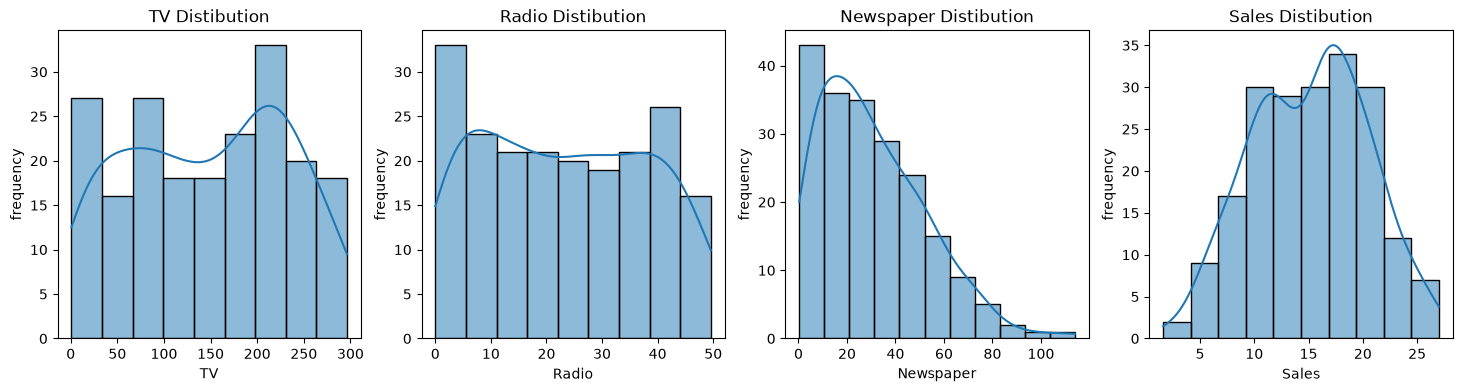

In [21]:
# Histogram with kde for each of the features
fig, axes = plt.subplots(1,4, figsize = (18, 4))

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde = True, ax = axes[i])
    axes[i].set_title(f"{col} Distibution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('frequency')

plt.show()

- TV and Radio has the consistent expenses
- The newspaper has inconsistent as it has maximum between 10-30
- Sales follows the normal distibution

## Outliers

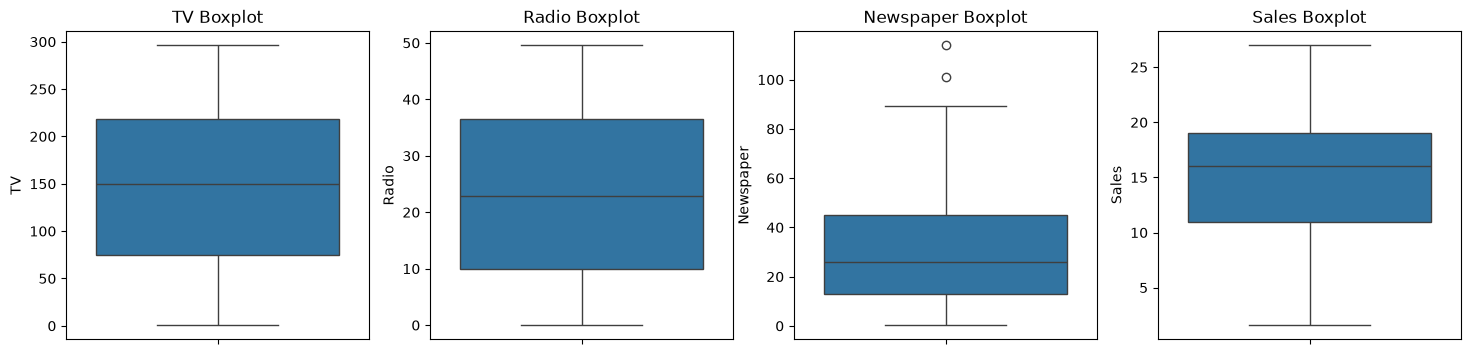

In [23]:
fig, axes = plt.subplots(1,4,figsize=(18,4))

for i,col in enumerate(df.columns):
    sns.boxplot(y = df[col], ax = axes[i])
    axes[i].set_title(f"{col} Boxplot")
    axes[i].set_ylabel(col)

plt.show()

- TV, Radio, Sales boxplot show that there is no outliers but, 
- Newspaper boxplot shows that there i an outliers 

## Scatter Plots --Features vs sales

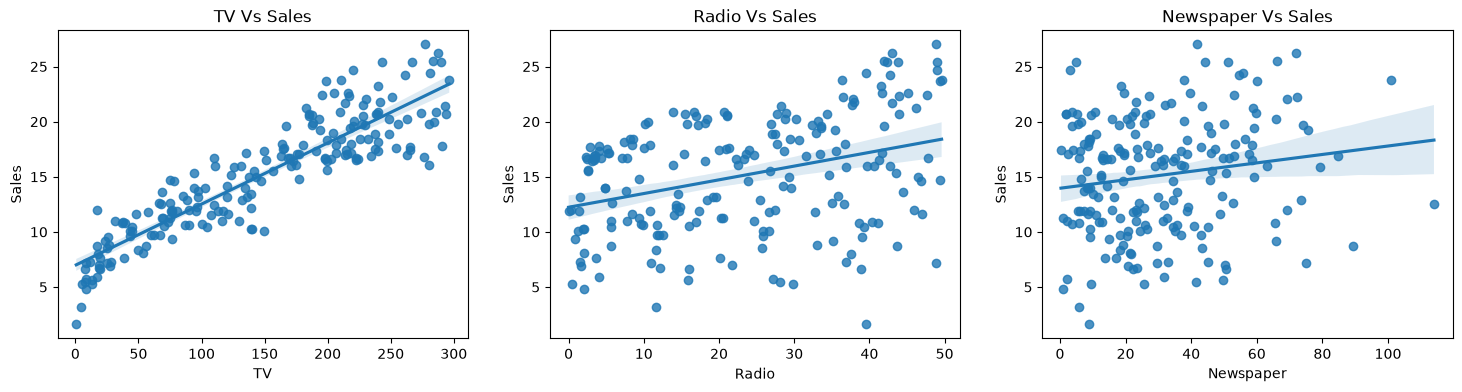

In [26]:
features = df.columns[:-1]
targets = df.columns[-1]

fig, axes = plt.subplots(1,3,figsize=(18,4))

for i,feature in enumerate(features):
    sns.regplot(x = df[feature], y = df[targets], ax = axes[i])
    axes[i].set_title(f"{feature} Vs {targets}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(targets)

plt.show()

- From TV vs Sales, we came to know that when the expenses in tv increases the sales also increases
- From Radio vs Sales, we came to know that when the expenses in radio increases the sales also increases but not just like the tv vs sales, radio has moderate effects in sales
- From newspaper vs Sales, we came to know that when the expenses in newpaper has little effect in it

## Correlation Matrix

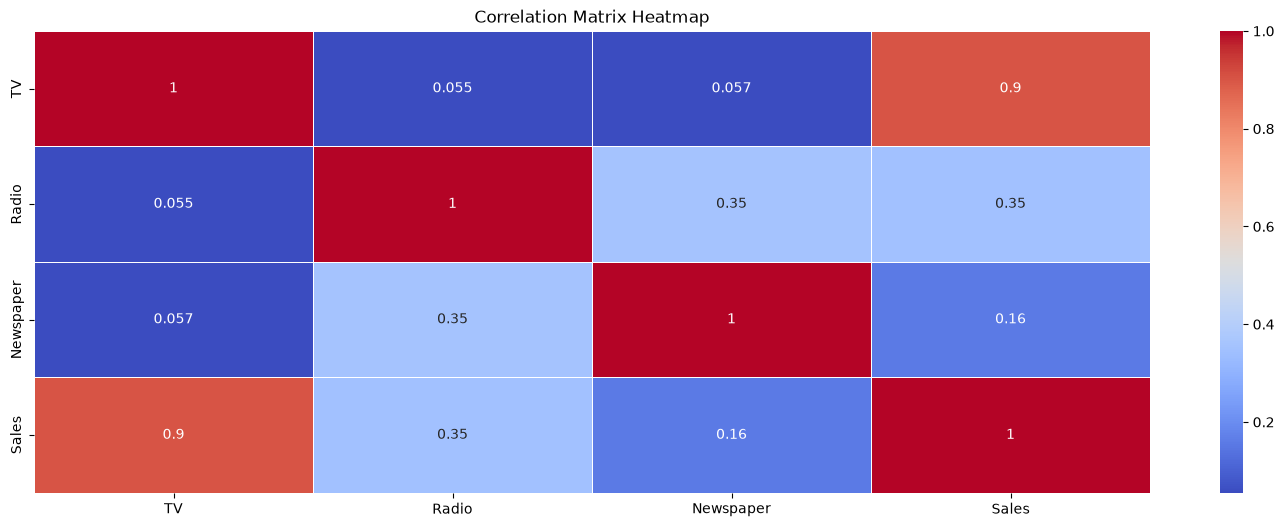

In [29]:
plt.figure(figsize=(18,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

- We can see that the tv is highly correlated with the sales nearly to 1
- And, newspaper is least coorelated with sales nearly to 0

### Pairplot

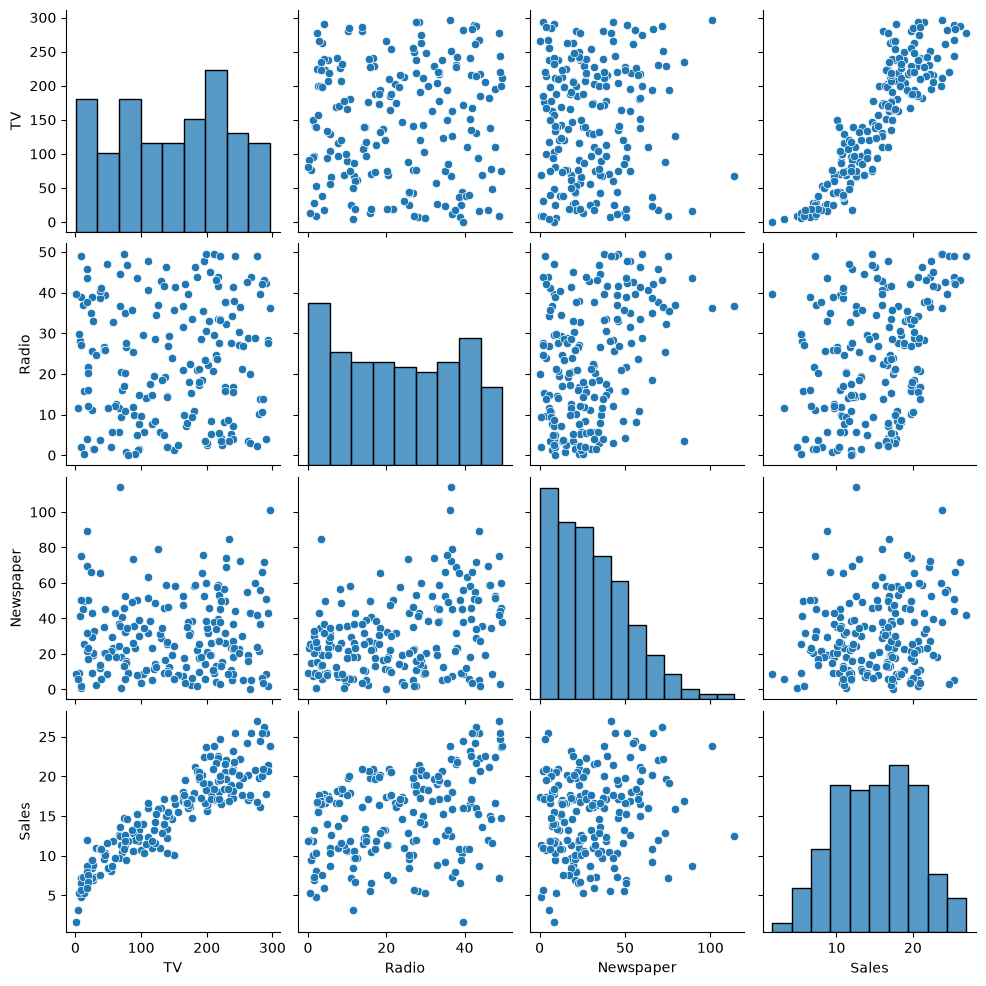

In [30]:
sns.pairplot(df)

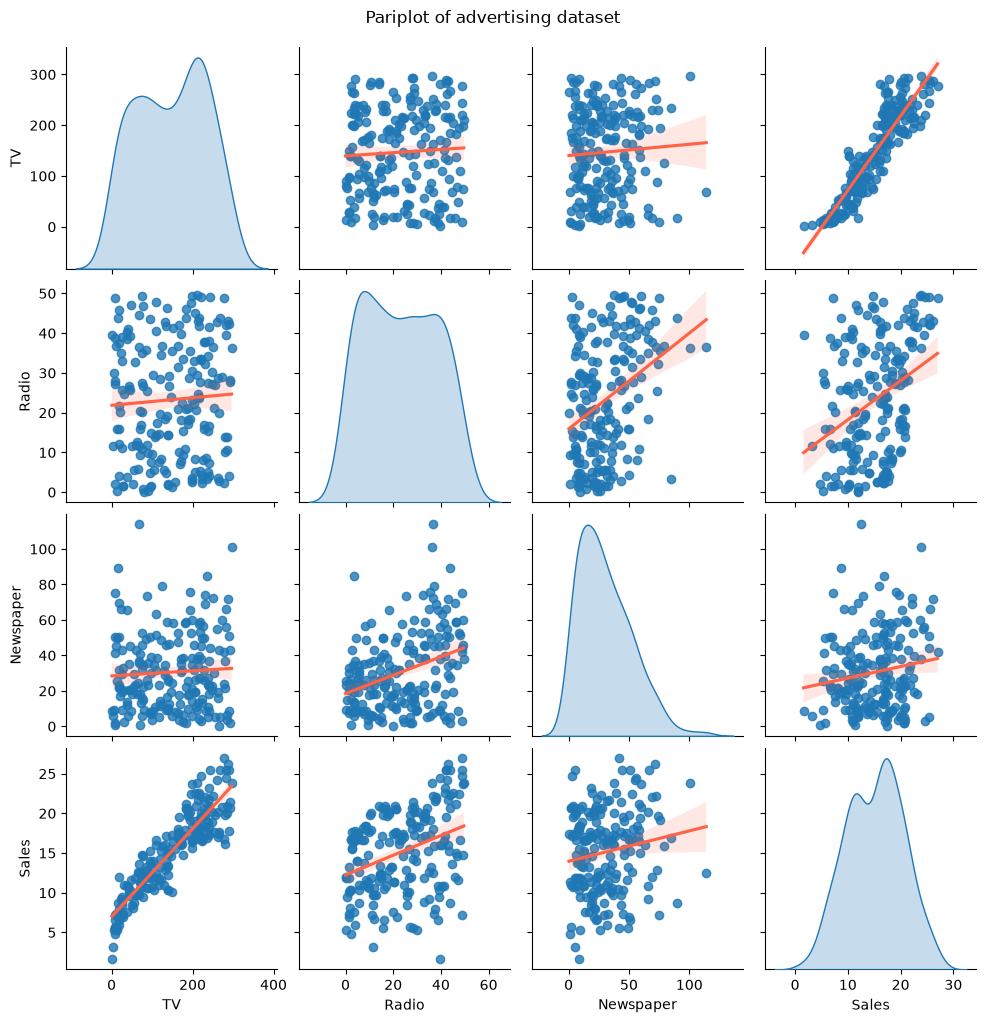

In [36]:
sns.pairplot(df, kind = 'reg', diag_kind='kde', plot_kws={'line_kws': {'color': 'tomato'}})
plt.suptitle("Pariplot of advertising dataset", y = 1.02)
plt.show()

## Preparing data for Modeling
### Define feature and targets

In [37]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(150, 3)
(50, 3)
(150,)
(50,)


## Building a Model

### Simple Linear Regression (TV only)
as tv is highly correlated with sales

In [40]:
from sklearn.linear_model import LinearRegression

slr = LinearRegression()
slr.fit(X_train[['TV']], y_train)
y_pred_slr = slr.predict(X_test[['TV']])

<Axes: xlabel='TV', ylabel='Sales'>

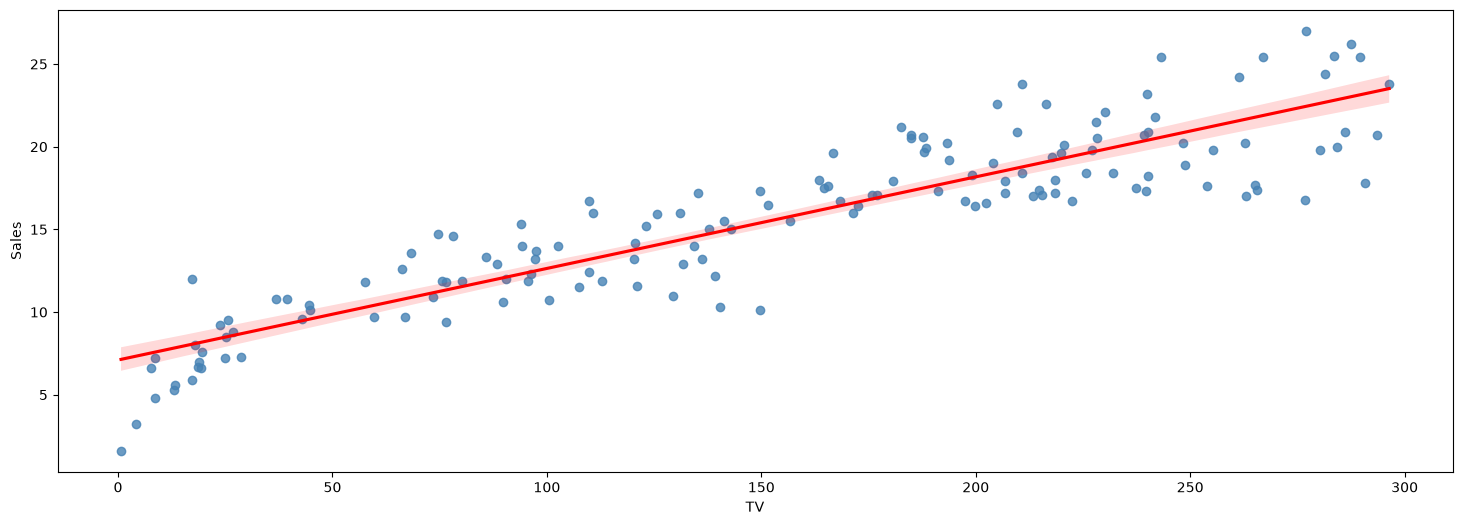

In [ ]:
# visulize the SRL on training data
plt.figure(figsize=(18,6))
sns.regplot(x = X_train[['TV']], y = y_train, color = 'steelblue', line_kws = {'color':'red'})
plt.xlabel("TV A")

#### The above given line is the most promising regression line.

## Evaluate the simple model on test set

In [42]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

mse_slr = mean_squared_error(y_test, y_pred_slr)
r2_slr = r2_score(y_test, y_pred_slr)
mae_slr = mean_absolute_error(y_test, y_pred_slr)

print("---Simple Linear Regression---Test set Performance")
print(f"R-squared: {r2_slr:.2f}")
print(f"Mean Absolute Error: {mae_slr:.2f}")
print(f"Mean Square error: {mse_slr:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse_slr):.4f}")

---Simple Linear Regression---Test set Performance
R-squared: 0.80
Mean Absolute Error: 1.87
Mean Square error: 5.51
Root Mean Squared Error: 2.3481


## Multiple Linear Regression(TV, Radio, Newspaper)

In [43]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)
y_pred_mlr = mlr.predict(X_test)

The learned coefficients and intercept of multiple linear regression model.

In [46]:
print("---Multiple Linear Regression Coefficient---")
print(f"Intercept (beta_0): {mlr.intercept_:.4f}")
for i,col in enumerate(X.columns):
    print(f"Coefficient for {col} (beta_{i+1}): {mlr.coef_[i]:.4f}")

---Multiple Linear Regression Coefficient---
Intercept (beta_0): 4.7418
Coefficient for TV (beta_1): 0.0546
Coefficient for Radio (beta_2): 0.0998
Coefficient for Newspaper (beta_3): 0.0043


##### Model Evaluation(mlr)

In [47]:
mse_mlr = mean_squared_error(y_test,y_pred_mlr)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)


print("---Multiple Linear Regression---Test set Performance")
print(f"R-squared: {r2_mlr:.2f}")
print(f"Mean Absolute Error: {mae_mlr:.2f}")
print(f"Mean Square error: {mse_mlr:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse_mlr):.4f}")

---Multiple Linear Regression---Test set Performance
R-squared: 0.91
Mean Absolute Error: 1.12
Mean Square error: 2.40
Root Mean Squared Error: 1.5505


## Compresion between the Slr and Mlr

-   ---Simple Linear Regression---Test set Performance

    R-squared: 0.80

    Mean Absolute Error: 1.87

    Mean Square error: 5.51

    Root Mean Squared Error: 2.3481

-   ---Multiple Linear Regression---Test set Performance

    R-squared: 0.91

    Mean Absolute Error: 1.12

    Mean Square error: 2.40
    
    Root Mean Squared Error: 1.5505

#### With this compresion we can say that the slr is less efficient than mlr as from the r-squared value

## Actual Vs Predicted sales (multiple Linear Regression Model)

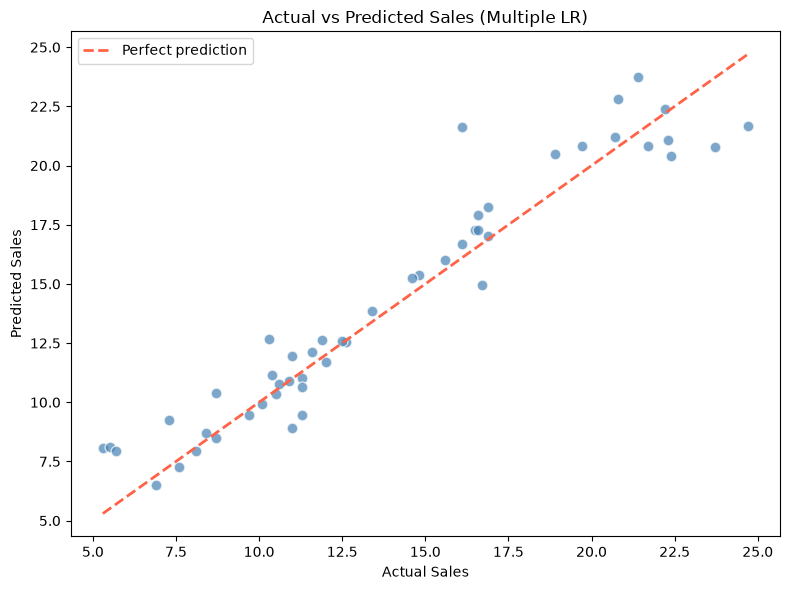

In [48]:
# actual vs predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_mlr, alpha=0.7, color='steelblue', edgecolors='white', s=60)
# perfect prediction line
mn, mx = min(y_test.min(), y_pred_mlr.min()), max(y_test.max(), y_pred_mlr.max())
plt.plot([mn, mx], [mn, mx], color='tomato', linewidth=2, linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Multiple LR)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\A\AppData\Local\Temp\ipykernel_7572\930489951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = X_train.columns, y = mlr.coef_, palette='viridis')


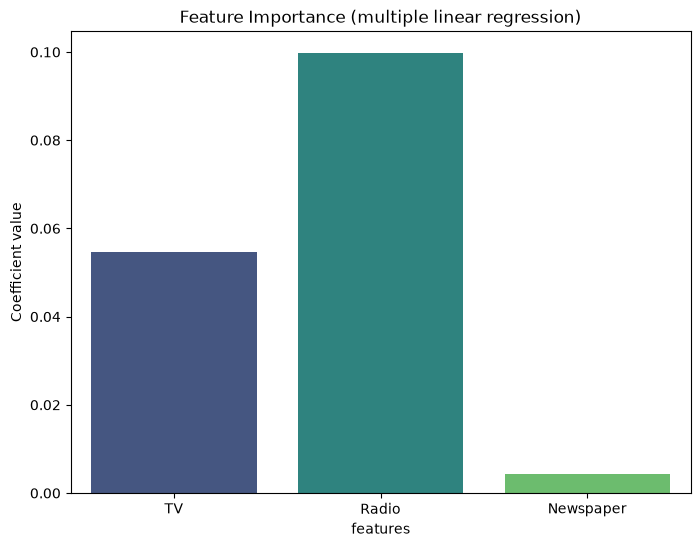

In [54]:
# Coefficient barchart plot to visually compare relative importance
plt.figure(figsize=(8,6))
sns.barplot(x = X_train.columns, y = mlr.coef_, palette='viridis')
plt.title('Feature Importance (multiple linear regression)')
plt.xlabel('features')
plt.ylabel('Coefficient value')
plt.show()

## Scale the Features for Multiple Linear Regression

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [66]:
mlr_scaled = LinearRegression()
mlr_scaled.fit(X_train_scale,y_train)
y_pred_mlr_scale = mlr_scaled.predict(X_test_scale)

print("---Multiple Linear Regression Coefficient Scale---")
print(f"Intercept (beta_0): {mlr_scaled.intercept_:.4f}")
for i,col in enumerate(X.columns):
    print(f"Coefficient for {col} (beta_{i+1}): {mlr_scaled.coef_[i]:.4f}")

---Multiple Linear Regression Coefficient Scale---
Intercept (beta_0): 15.5707
Coefficient for TV (beta_1): 4.6320
Coefficient for Radio (beta_2): 1.4821
Coefficient for Newspaper (beta_3): 0.0889


#### Comparing the coefficient and intercept between the scaled and not scaled mlr

-   ---Multiple Linear Regression Coefficient---

    Intercept (beta_0): 4.7418

    Coefficient for TV (beta_1): 0.0546

    Coefficient for Radio (beta_2): 0.0998

    Coefficient for Newspaper (beta_3): 0.0043


-   ---Multiple Linear Regression Coefficient Scale---

    Intercept (beta_0): 15.5707

    Coefficient for TV (beta_1): 4.6320

    Coefficient for Radio (beta_2): 1.4821

    Coefficient for Newspaper (beta_3): 0.0889


#### In conclusion we can predicts that:
- Without scaling the coefficient of tv was less than that of the radio although the tv was highly correlated with the sales.
- After scaling the coefficient of tv becomes the most than that of the radio

C:\Users\A\AppData\Local\Temp\ipykernel_7572\3063755861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = X_train.columns, y = mlr_scaled.coef_, palette='viridis')


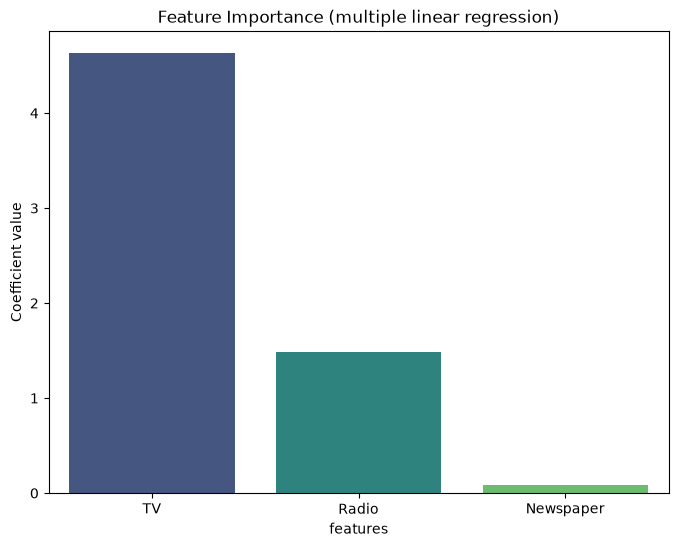

In [67]:
# Coefficient barchart plot to visually compare relative importance
plt.figure(figsize=(8,6))
sns.barplot(x = X_train.columns, y = mlr_scaled.coef_, palette='viridis')
plt.title('Feature Importance (multiple linear regression)')
plt.xlabel('features')
plt.ylabel('Coefficient value')
plt.show()

In [68]:
mse_mlr = mean_squared_error(y_test, y_pred_mlr_scale)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr_scale)
r2_mlr = r2_score(y_test, y_pred_mlr_scale)


print("---Multiple Linear Regression---Test set Performance")
print(f"R-squared: {r2_mlr:.2f}")
print(f"Mean Absolute Error: {mae_mlr:.2f}")
print(f"Mean Square error: {mse_mlr:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse_mlr):.4f}")

---Multiple Linear Regression---Test set Performance
R-squared: 0.91
Mean Absolute Error: 1.12
Mean Square error: 2.40
Root Mean Squared Error: 1.5505


In [65]:
X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.9115647723992757
MAE: 1.1199940713361776
MSE: 2.404067444711889
RMSE: 1.5505055448826648


## Summary

Here is what we went through:

| Step | What we did |
|------|------------|
| Data loading | Loaded the Advertising dataset (200 observations, 4 columns) |
| Data description | Checked types, missing values, and summary statistics |
| EDA | Histograms, boxplots, scatter plots, correlation matrix, pair plot |
| Simple LR | Built a model with TV alone -- decent but leaves variance on the table |
| Multiple LR | Added Radio and Newspaper -- significant improvement in R-squared |
| Evaluation | Compared R2, MAE, and RMSE across both models |
| Residuals | Checked normality, homoscedasticity, and independence of residuals |
| Interpretation | Read the coefficients to understand the business impact of each channel |

**Key takeaways:**
- TV is the single most important predictor, but Radio adds substantial value.
- Newspaper contributes very little once the other two are accounted for.
- The multiple regression model explains a large share of the variance in Sales.
- Residuals are reasonably well-behaved, which means the model's assumptions hold up here.

From a business perspective, a marketing team looking at this data would probably want to prioritise TV and Radio budgets and reconsider how much they invest in Newspaper advertising.